## 1️⃣ Conexión a BigQuery y carga de datos
Cargamos la vista maestra construida en la Fase 1 (2.163 ofertas, 26 columnas) directamente desde BigQuery.

In [12]:
from google.colab import auth
from google.cloud import bigquery

auth.authenticate_user()

proyecto = 'tfm-mercado-laboral-datos'
client = bigquery.Client(project=proyecto)

query = """
SELECT *
FROM `tfm-mercado-laboral-datos.mercado_laboral_datos.vista_maestra_mercado_laboral`
"""

df = client.query(query).to_dataframe()
df.shape

(2163, 26)

## 2️⃣ Preparación de variables estructuradas
Reconstruimos modalidad de trabajo, nivel de experiencia y salario (ya validados en la Fase 2), añadimos el número de skills técnicas por oferta a partir del diccionario de la Fase 3, y derivamos la industria principal de cada oferta — resolviendo por el camino un problema real de formato en ese campo.

In [13]:
df['remote_allowed'].value_counts(dropna=False)

,count
remote_allowed,
NaN,1520
1.0,643


In [14]:
df['modalidad_remoto'] = df['remote_allowed'].map({1.0: 'Remoto'}).fillna('No especificado')
df['modalidad_remoto'].value_counts()

,count
modalidad_remoto,
No especificado,1520
Remoto,643


In [15]:
df['formatted_experience_level'].value_counts(dropna=False)

,count
formatted_experience_level,
Mid-Senior level,1040
None,631
Entry level,275
Associate,151
Director,32
Internship,27
Executive,7


In [16]:
df['formatted_experience_level'] = df['formatted_experience_level'].fillna('No especificado')
df['formatted_experience_level'].value_counts()

,count
formatted_experience_level,
Mid-Senior level,1040
No especificado,631
Entry level,275
Associate,151
Director,32
Internship,27
Executive,7


In [17]:
df['pay_period'].value_counts(dropna=False)

,count
pay_period,
None,1498
YEARLY,457
HOURLY,203
MONTHLY,5


In [18]:
factor_anual = {'YEARLY': 1, 'MONTHLY': 12, 'HOURLY': 2080}
df['factor_anual'] = df['pay_period'].map(factor_anual)

df['salario_min_anual'] = df['min_salary'] * df['factor_anual']
df['salario_max_anual'] = df['max_salary'] * df['factor_anual']

df[['pay_period', 'min_salary', 'factor_anual', 'salario_min_anual']].dropna().head(10)

,pay_period,min_salary,factor_anual,salario_min_anual
2,YEARLY,60000.0,1.0,60000.0
7,HOURLY,101.0,2080.0,210080.0
9,YEARLY,150000.0,1.0,150000.0
13,YEARLY,95000.0,1.0,95000.0
24,YEARLY,60000.0,1.0,60000.0
27,YEARLY,61261.0,1.0,61261.0
30,YEARLY,100000.0,1.0,100000.0
32,YEARLY,88854.0,1.0,88854.0
42,YEARLY,77265.0,1.0,77265.0
43,HOURLY,35.0,2080.0,72800.0


In [19]:
df[['salario_min_anual', 'salario_max_anual']].describe()

,salario_min_anual,salario_max_anual
count,622.000000,6.220000e+02
mean,113876.646158,1.775830e+05
std,42871.019370,5.458220e+05
min,30.000000,3.500000e+01
25%,83200.000000,1.144000e+05
50%,110000.000000,1.456000e+05
75%,140000.000000,1.872000e+05
max,400000.000000,1.366560e+07


In [20]:
df[(df['salario_min_anual'] < 1000) | (df['salario_max_anual'] > 500000)][
    ['title', 'pay_period', 'min_salary', 'max_salary', 'salario_min_anual', 'salario_max_anual']
]

,title,pay_period,min_salary,max_salary,salario_min_anual,salario_max_anual
142,Java-Big Data Architect,YEARLY,75.0,85.0,75.0,85.0
215,"ML Engineer L5, LLM Application Frameworks, Ma...",YEARLY,100000.0,720000.0,100000.0,720000.0
279,Vice President of Data Engineering,YEARLY,400000.0,600000.0,400000.0,600000.0
542,Information Technology Business Analyst,YEARLY,60.0,65.0,60.0,65.0
645,Data Engineer,HOURLY,65.0,6570.0,135200.0,13665600.0
662,Business Analyst 24-02965,YEARLY,30.0,35.0,30.0,35.0
873,Sr. Data Engineer,YEARLY,70.0,80.0,70.0,80.0
1091,Data Architect,YEARLY,70.0,75.0,70.0,75.0
1444,Full Time - Financial Business Analyst with Re...,YEARLY,50.0,55.0,50.0,55.0
1611,Finance Senior Oracle Fusion Business Analyst,YEARLY,150.0,150.0,150.0,150.0


In [21]:
df.loc[(df['salario_min_anual'] < 1000) | (df['salario_min_anual'] > 1000000), 'salario_min_anual'] = None
df.loc[(df['salario_max_anual'] < 1000) | (df['salario_max_anual'] > 1000000), 'salario_max_anual'] = None

df[['salario_min_anual', 'salario_max_anual']].describe()

,salario_min_anual,salario_max_anual
count,614.000000,613.000000
mean,115359.485195,157896.340538
std,41117.803429,65093.008124
min,37315.200000,47840.000000
25%,84300.000000,114400.000000
50%,110000.000000,145600.000000
75%,141080.000000,187200.000000
max,400000.000000,720000.000000


In [22]:
import re

def limpiar_texto_ligero(texto):
    if texto is None:
        return ""
    texto = re.sub(r'([a-z])([A-Z])', r'\1 \2', texto)
    return texto.lower()

df['descripcion_limpia'] = df['description'].apply(limpiar_texto_ligero)

In [23]:
diccionario_skills = {
    'Python': [r'\bpython\b'],
    'SQL': [r'\bsql\b'],
    'R': [r'\br\b'],
    'Java': [r'\bjava\b'],
    'Scala': [r'\bscala\b'],
    'VBA': [r'\bvba\b'],
    'Excel': [r'\bexcel\b'],
    'Power BI': [r'\bpower\s?bi\b'],
    'Tableau': [r'\btableau\b'],
    'Looker': [r'\blooker\b'],
    'Qlik': [r'\bqlik\b'],
    'SAP': [r'\bsap\b'],
    'Salesforce': [r'\bsalesforce\b'],
    'Alteryx': [r'\balteryx\b'],
    'AWS': [r'\baws\b'],
    'Azure': [r'\bazure\b'],
    'Google Cloud': [r'\bgcp\b', r'\bgoogle cloud\b'],
    'Snowflake': [r'\bsnowflake\b'],
    'Redshift': [r'\bredshift\b'],
    'BigQuery': [r'\bbigquery\b', r'\bbig query\b'],
    'Databricks': [r'\bdatabricks\b'],
    'Spark': [r'\bspark\b'],
    'Hadoop': [r'\bhadoop\b'],
    'Kafka': [r'\bkafka\b'],
    'Airflow': [r'\bairflow\b'],
    'ETL': [r'\betl\b'],
    'MySQL': [r'\bmysql\b'],
    'PostgreSQL': [r'\bpostgresql\b', r'\bpostgres\b'],
    'MongoDB': [r'\bmongodb\b'],
    'NoSQL': [r'\bnosql\b'],
    'Machine Learning': [r'\bmachine learning\b'],
    'Deep Learning': [r'\bdeep learning\b'],
    'TensorFlow': [r'\btensorflow\b'],
    'PyTorch': [r'\bpytorch\b'],
    'Scikit-learn': [r'\bscikit-learn\b', r'\bsklearn\b'],
    'Pandas': [r'\bpandas\b'],
    'NumPy': [r'\bnumpy\b'],
    'Git': [r'\bgit\b'],
    'Docker': [r'\bdocker\b'],
    'Kubernetes': [r'\bkubernetes\b'],
    'Jira': [r'\bjira\b'],
    'Agile': [r'\bagile\b'],
    'Scrum': [r'\bscrum\b'],
    'DAX': [r'\bdax\b'],
}

def detectar_skills(texto, diccionario):
    encontradas = []
    for skill, patrones in diccionario.items():
        for patron in patrones:
            if re.search(patron, texto):
                encontradas.append(skill)
                break
    return encontradas

df['skills_detectadas'] = df['descripcion_limpia'].apply(lambda t: detectar_skills(t, diccionario_skills))

In [24]:
diccionario_skills['R'] = [r'\br\b(?!\s*&\s*d)']
diccionario_skills['C++'] = [r'c\+\+']

df['skills_detectadas'] = df['descripcion_limpia'].apply(lambda t: detectar_skills(t, diccionario_skills))

In [25]:
df['num_skills'] = df['skills_detectadas'].apply(len)
df['num_skills'].describe()

,num_skills
count,2163.000000
mean,4.081368
std,3.308224
min,0.000000
25%,2.000000
50%,3.000000
75%,6.000000
max,19.000000


In [26]:
df['skills_detectadas'].explode().value_counts().head(10)

,count
skills_detectadas,
SQL,1135
Python,943
Machine Learning,517
Agile,491
AWS,426
Excel,404
Azure,382
Power BI,358
ETL,352


In [27]:
df['industria_principal'] = df['industrias_lista'].apply(lambda lista: lista[0] if lista is not None and len(lista) > 0 else None)
df['industria_principal'].value_counts(dropna=False)

,count
industria_principal,
I,730
S,375
F,232
H,145
B,139
T,121
M,58
R,49
A,47


In [28]:
print(df['industrias_lista'].iloc[0])
print(type(df['industrias_lista'].iloc[0]))

IT Services and IT Consulting
<class 'str'>


In [29]:
df['industrias_lista'].apply(lambda x: ',' in x if isinstance(x, str) else False).sum()

np.int64(534)

In [30]:
df[df['industrias_lista'].apply(lambda x: isinstance(x, str) and ',' in x)]['industrias_lista'].head(10)

,industrias_lista
3,"Motor Vehicle Manufacturing, IT Services and I..."
6,"Technology, Information and Internet"
8,"Technology, Information and Internet"
14,"Biotechnology Research, Pharmaceutical Manufac..."
20,"Insurance, IT Services and IT Consulting"
24,"Pharmaceutical Manufacturing, Retail Pharmacies"
35,"Technology, Information and Media"
37,"Investment Banking, Capital Markets"
43,"Banking, IT Services and IT Consulting"
53,"Government Administration, Information Services"


In [31]:
df['industria_principal'] = df['industrias_lista'].apply(lambda x: x.split(',')[0].strip() if isinstance(x, str) else None)
df['industria_principal'].value_counts(dropna=False)

,count
industria_principal,
IT Services and IT Consulting,516
Software Development,262
Financial Services,219
Hospitals and Health Care,110
Staffing and Recruiting,93
...,...
Equipment Rental Services,1
Automation Machinery Manufacturing,1
Law Enforcement,1


In [32]:
umbral = 20
conteo_industrias = df['industria_principal'].value_counts()
industrias_frecuentes = conteo_industrias[conteo_industrias >= umbral].index

df['industria_principal'] = df['industria_principal'].apply(
    lambda x: x if x in industrias_frecuentes else 'Otras'
)
df['industria_principal'].value_counts(dropna=False)

,count
industria_principal,
IT Services and IT Consulting,516
Otras,353
Software Development,262
Financial Services,219
Hospitals and Health Care,110
Staffing and Recruiting,93
Technology,75
Insurance,66
Information Services,65


## 3️⃣ Random Forest: prediciendo el rol sin leer el texto
Entrenamos un Random Forest para predecir la categoría de rol usando solo industria, modalidad, experiencia y número de skills, y lo evaluamos con matriz de confusión, importancia de variables (por impureza y por permutación) y validación cruzada.

In [33]:
from sklearn.feature_extraction import DictVectorizer

columnas_features = ['industria_principal', 'modalidad_remoto', 'formatted_experience_level', 'num_skills']
df_modelo = df[columnas_features + ['categoria_rol']].dropna()

vectorizador = DictVectorizer(sparse=False)
X = vectorizador.fit_transform(df_modelo[columnas_features].to_dict('records'))
y = df_modelo['categoria_rol']

print(X.shape)
print(vectorizador.get_feature_names_out())

(2163, 32)
['formatted_experience_level=Associate'
 'formatted_experience_level=Director'
 'formatted_experience_level=Entry level'
 'formatted_experience_level=Executive'
 'formatted_experience_level=Internship'
 'formatted_experience_level=Mid-Senior level'
 'formatted_experience_level=No especificado'
 'industria_principal=Advertising Services' 'industria_principal=Banking'
 'industria_principal=Biotechnology Research'
 'industria_principal=Business Consulting and Services'
 'industria_principal=Defense and Space Manufacturing'
 'industria_principal=Entertainment Providers'
 'industria_principal=Financial Services'
 'industria_principal=Government Administration'
 'industria_principal=Higher Education'
 'industria_principal=Hospitals and Health Care'
 'industria_principal=IT Services and IT Consulting'
 'industria_principal=Information Services'
 'industria_principal=Information Technology & Services'
 'industria_principal=Insurance' 'industria_principal=Manufacturing'
 'industria_p

In [34]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape, X_val.shape)

(1730, 32) (433, 32)


In [35]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=20,
    min_samples_split=5,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_val)
accuracy = accuracy_score(y_val, y_pred)

print(f"Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")
print(classification_report(y_val, y_pred))

Accuracy: 0.4319 (43.19%)
                           precision    recall  f1-score   support

   BI Analyst / Developer       0.21      0.34      0.26        38
         Business Analyst       0.61      0.68      0.64       111
             Data Analyst       0.57      0.26      0.35        82
           Data Architect       0.15      0.19      0.17        26
            Data Engineer       0.47      0.32      0.38        79
           Data Scientist       0.43      0.51      0.47        70
Machine Learning Engineer       0.30      0.44      0.36        27

                 accuracy                           0.43       433
                macro avg       0.39      0.39      0.38       433
             weighted avg       0.47      0.43      0.43       433



In [36]:
!pip install -q kaleido==0.2.1
import plotly.io as pio
pio.renderers.default = "png"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.9/79.9 MB 11.3 MB/s eta 0:00:00


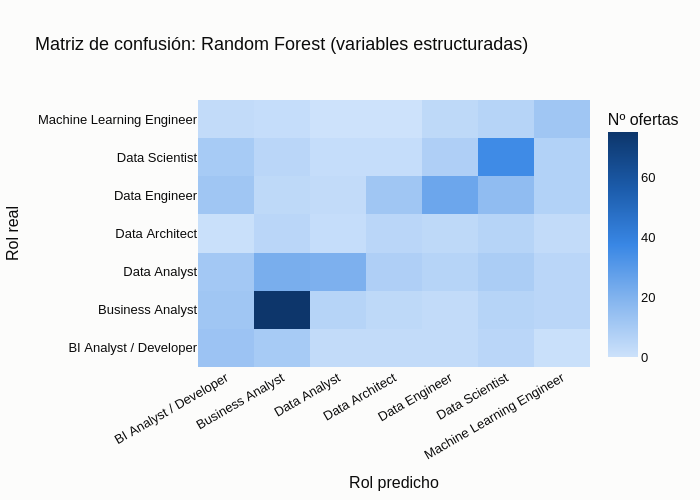

In [38]:
import pandas as pd
import plotly.graph_objects as go
from sklearn.metrics import confusion_matrix

etiquetas = sorted(y.unique())
matriz_confusion = confusion_matrix(y_val, y_pred, labels=etiquetas)
matriz_confusion_df = pd.DataFrame(matriz_confusion, index=etiquetas, columns=etiquetas)

colorscale_azul = [
    [0.0, '#cde2fb'],
    [0.25, '#86b6ef'],
    [0.5, '#3987e5'],
    [0.75, '#1c5cab'],
    [1.0, '#0d366b'],
]

fig = go.Figure(data=go.Heatmap(
    z=matriz_confusion_df.values,
    x=matriz_confusion_df.columns,
    y=matriz_confusion_df.index,
    colorscale=colorscale_azul,
    colorbar=dict(title='Nº ofertas'),
    hovertemplate='Real: %{y}<br>Predicho: %{x}<br>%{z} ofertas<extra></extra>',
))

fig.update_layout(
    title='Matriz de confusión: Random Forest (variables estructuradas)',
    xaxis_title='Rol predicho',
    yaxis_title='Rol real',
    plot_bgcolor='#fcfcfb',
    paper_bgcolor='#fcfcfb',
    font=dict(color='#0b0b0b', size=13),
    margin=dict(l=180, b=120),
)
fig.update_xaxes(tickangle=-30)
fig.show()

In [39]:
importancias = pd.DataFrame({
    'variable': vectorizador.get_feature_names_out(),
    'importancia': rf_model.feature_importances_
}).sort_values('importancia', ascending=False)

importancias.head(15)

,variable,importancia
31,num_skills,0.439670
2,formatted_experience_level=Entry level,0.040498
30,modalidad_remoto=Remoto,0.035838
5,formatted_experience_level=Mid-Senior level,0.035039
29,modalidad_remoto=No especificado,0.033740
6,formatted_experience_level=No especificado,0.032853
25,industria_principal=Software Development,0.031167
17,industria_principal=IT Services and IT Consulting,0.029780
22,industria_principal=Otras,0.029438
13,industria_principal=Financial Services,0.023310


In [40]:
from sklearn.inspection import permutation_importance

resultado_permutacion = permutation_importance(
    rf_model, X_val, y_val,
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

importancias_permutacion = pd.DataFrame({
    'variable': vectorizador.get_feature_names_out(),
    'importancia': resultado_permutacion.importances_mean
}).sort_values('importancia', ascending=False)

importancias_permutacion.head(15)

,variable,importancia
31,num_skills,0.196998
17,industria_principal=IT Services and IT Consulting,0.026097
2,formatted_experience_level=Entry level,0.025635
13,industria_principal=Financial Services,0.021478
25,industria_principal=Software Development,0.014319
6,formatted_experience_level=No especificado,0.011778
28,industria_principal=Telecommunications,0.009700
29,modalidad_remoto=No especificado,0.006928
12,industria_principal=Entertainment Providers,0.006697
30,modalidad_remoto=Remoto,0.006467


In [41]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rf_cv = RandomForestClassifier(
    n_estimators=100,
    max_depth=20,
    min_samples_split=5,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

scores_cv = cross_val_score(rf_cv, X, y, cv=skf, scoring='accuracy')

print("Accuracy por fold:", scores_cv)
print(f"Accuracy media: {scores_cv.mean():.4f} ± {scores_cv.std():.4f}")

Accuracy por fold: [0.38568129 0.38106236 0.44341801 0.44907407 0.43981481]
Accuracy media: 0.4198 ± 0.0299


### Modelo complementario: añadiendo el salario
Repetimos el proceso incluyendo el salario, restringido a las 613 ofertas donde el dato es real, para no inventar valores sobre el 72% restante.

In [42]:
df['salario_mediana_oferta'] = (df['salario_min_anual'] + df['salario_max_anual']) / 2

columnas_features_v2 = columnas_features + ['salario_mediana_oferta']
df_modelo_salario = df[columnas_features_v2 + ['categoria_rol']].dropna()

print(df_modelo_salario.shape)

(613, 6)


In [43]:
vectorizador_salario = DictVectorizer(sparse=False)
X_salario = vectorizador_salario.fit_transform(df_modelo_salario[columnas_features_v2].to_dict('records'))
y_salario = df_modelo_salario['categoria_rol']

X_train_s, X_val_s, y_train_s, y_val_s = train_test_split(
    X_salario, y_salario,
    test_size=0.2,
    random_state=42,
    stratify=y_salario
)

rf_salario = RandomForestClassifier(
    n_estimators=100,
    max_depth=20,
    min_samples_split=5,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf_salario.fit(X_train_s, y_train_s)
y_pred_s = rf_salario.predict(X_val_s)
accuracy_s = accuracy_score(y_val_s, y_pred_s)

print(f"Accuracy (con salario, n={len(df_modelo_salario)}): {accuracy_s:.4f} ({accuracy_s*100:.2f}%)")
print(classification_report(y_val_s, y_pred_s))

Accuracy (con salario, n=613): 0.4553 (45.53%)
                           precision    recall  f1-score   support

   BI Analyst / Developer       0.33      0.17      0.22        12
         Business Analyst       0.52      0.52      0.52        27
             Data Analyst       0.39      0.30      0.34        23
           Data Architect       0.22      0.40      0.29         5
            Data Engineer       0.65      0.54      0.59        24
           Data Scientist       0.48      0.59      0.53        22
Machine Learning Engineer       0.31      0.50      0.38        10

                 accuracy                           0.46       123
                macro avg       0.42      0.43      0.41       123
             weighted avg       0.47      0.46      0.45       123



In [44]:
resultado_permutacion_salario = permutation_importance(
    rf_salario, X_val_s, y_val_s,
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

importancias_salario = pd.DataFrame({
    'variable': vectorizador_salario.get_feature_names_out(),
    'importancia': resultado_permutacion_salario.importances_mean
}).sort_values('importancia', ascending=False)

importancias_salario.head(10)

,variable,importancia
31,num_skills,0.156098
32,salario_mediana_oferta,0.143902
8,industria_principal=Banking,0.018699
28,industria_principal=Telecommunications,0.016260
5,formatted_experience_level=Mid-Senior level,0.012195
12,industria_principal=Entertainment Providers,0.007317
25,industria_principal=Software Development,0.004878
26,industria_principal=Staffing and Recruiting,0.003252
1,formatted_experience_level=Director,0.002439
23,industria_principal=Pharmaceutical Manufacturing,0.000813


In [45]:
scores_cv_salario = cross_val_score(rf_salario, X_salario, y_salario, cv=skf, scoring='accuracy')

print("Accuracy por fold:", scores_cv_salario)
print(f"Accuracy media: {scores_cv_salario.mean():.4f} ± {scores_cv_salario.std():.4f}")

Accuracy por fold: [0.45528455 0.40650407 0.3902439  0.45901639 0.48360656]
Accuracy media: 0.4389 ± 0.0349


### Ajuste de hiperparámetros (GridSearchCV)
Buscamos la mejor combinación de hiperparámetros optimizando F1 macro, y la comparamos con el modelo base antes de adoptarla.

In [46]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
}

grid_search = GridSearchCV(
    RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1),
    param_grid=param_grid,
    cv=skf,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print("Mejores parámetros:", grid_search.best_params_)
print(f"Mejor F1 macro (CV): {grid_search.best_score_:.4f}")

Fitting 5 folds for each of 108 candidates, totalling 540 fits
Mejores parámetros: {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 200}
Mejor F1 macro (CV): 0.3705


In [47]:
from sklearn.metrics import f1_score

mejor_modelo = grid_search.best_estimator_
y_pred_tuned = mejor_modelo.predict(X_val)

accuracy_tuned = accuracy_score(y_val, y_pred_tuned)
f1_macro_tuned = f1_score(y_val, y_pred_tuned, average='macro')
f1_macro_baseline = f1_score(y_val, y_pred, average='macro')

print(f"Modelo base:     accuracy={accuracy:.4f}, F1 macro={f1_macro_baseline:.4f}")
print(f"Modelo ajustado: accuracy={accuracy_tuned:.4f}, F1 macro={f1_macro_tuned:.4f}")
print()
print(classification_report(y_val, y_pred_tuned))

Modelo base:     accuracy=0.4319, F1 macro=0.3750
Modelo ajustado: accuracy=0.4203, F1 macro=0.3654

                           precision    recall  f1-score   support

   BI Analyst / Developer       0.18      0.34      0.24        38
         Business Analyst       0.58      0.70      0.64       111
             Data Analyst       0.67      0.24      0.36        82
           Data Architect       0.15      0.19      0.17        26
            Data Engineer       0.42      0.35      0.39        79
           Data Scientist       0.43      0.37      0.40        70
Machine Learning Engineer       0.32      0.44      0.38        27

                 accuracy                           0.42       433
                macro avg       0.39      0.38      0.37       433
             weighted avg       0.47      0.42      0.42       433



## 4️⃣ K-Means: ¿surgen los roles de forma natural?
Escalamos las variables y exploramos el número óptimo de clústeres (codo y silhouette) antes de agrupar las ofertas sin decirle al algoritmo el rol real, para comprobar después cuánto coinciden los grupos con los roles conocidos.

In [48]:
from sklearn.preprocessing import StandardScaler

escalador = StandardScaler()
X_escalado = escalador.fit_transform(X)

print(X_escalado.mean(axis=0)[:5])
print(X_escalado.std(axis=0)[:5])

[-1.32056486e-15  4.78902375e-16 -1.66115131e-15  1.92608040e-17
 -2.17502084e-17]
[1. 1. 1. 1. 1.]


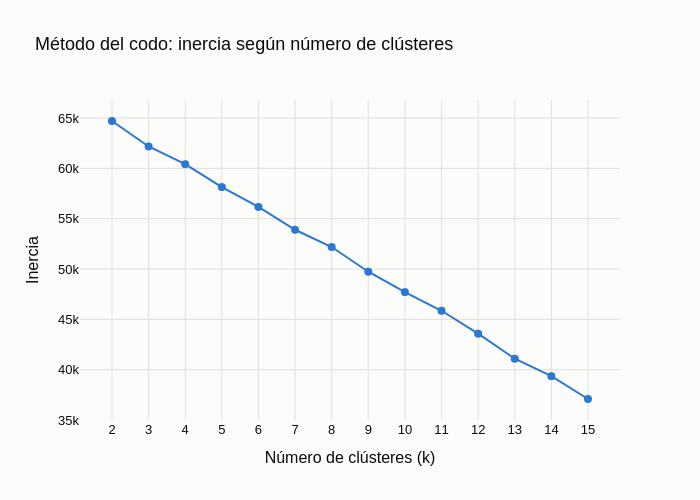

In [50]:
from sklearn.cluster import KMeans

inercias = []
rango_k = range(2, 16)

for k in rango_k:
    kmeans_prueba = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans_prueba.fit(X_escalado)
    inercias.append(kmeans_prueba.inertia_)

fig = go.Figure()
fig.add_trace(go.Scatter(
    x=list(rango_k), y=inercias,
    mode='lines+markers',
    line=dict(color='#2a78d6'),
    marker=dict(size=8),
))
fig.update_layout(
    title='Método del codo: inercia según número de clústeres',
    xaxis_title='Número de clústeres (k)',
    yaxis_title='Inercia',
    plot_bgcolor='#fcfcfb',
    paper_bgcolor='#fcfcfb',
    font=dict(color='#0b0b0b', size=13),
)
fig.update_xaxes(gridcolor='#e1e0d9', dtick=1)
fig.update_yaxes(gridcolor='#e1e0d9')
fig.show()

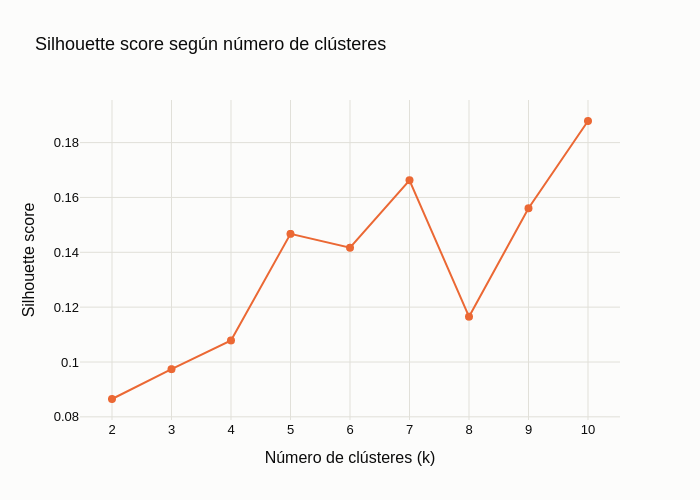

In [51]:
from sklearn.metrics import silhouette_score

silhouettes = []
rango_k_sil = range(2, 11)

for k in rango_k_sil:
    kmeans_prueba = KMeans(n_clusters=k, random_state=42, n_init=10)
    etiquetas_prueba = kmeans_prueba.fit_predict(X_escalado)
    silhouettes.append(silhouette_score(X_escalado, etiquetas_prueba))

fig = go.Figure()
fig.add_trace(go.Scatter(
    x=list(rango_k_sil), y=silhouettes,
    mode='lines+markers',
    line=dict(color='#eb6834'),
    marker=dict(size=8),
))
fig.update_layout(
    title='Silhouette score según número de clústeres',
    xaxis_title='Número de clústeres (k)',
    yaxis_title='Silhouette score',
    plot_bgcolor='#fcfcfb',
    paper_bgcolor='#fcfcfb',
    font=dict(color='#0b0b0b', size=13),
)
fig.update_xaxes(gridcolor='#e1e0d9', dtick=1)
fig.update_yaxes(gridcolor='#e1e0d9')
fig.show()

In [55]:
import numpy as np
import pandas as pd

kmeans = KMeans(n_clusters=7, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_escalado)

etiquetas_kmeans = np.empty(len(y), dtype=object)
for i in range(7):
    mascara = (clusters == i)
    etiquetas_kmeans[mascara] = pd.Series(y[mascara]).mode()[0]

accuracy_kmeans = accuracy_score(y, etiquetas_kmeans)
print(f"Accuracy K-Means (tras reasignar clústeres a rol mayoritario): {accuracy_kmeans:.4f} ({accuracy_kmeans*100:.2f}%)")

Accuracy K-Means (tras reasignar clústeres a rol mayoritario): 0.2705 (27.05%)


In [56]:
baseline_mayoritario = y.value_counts(normalize=True).max()
print(f"Baseline (predecir siempre el rol mayoritario): {baseline_mayoritario:.4f} ({baseline_mayoritario*100:.2f}%)")

Baseline (predecir siempre el rol mayoritario): 0.2557 (25.57%)


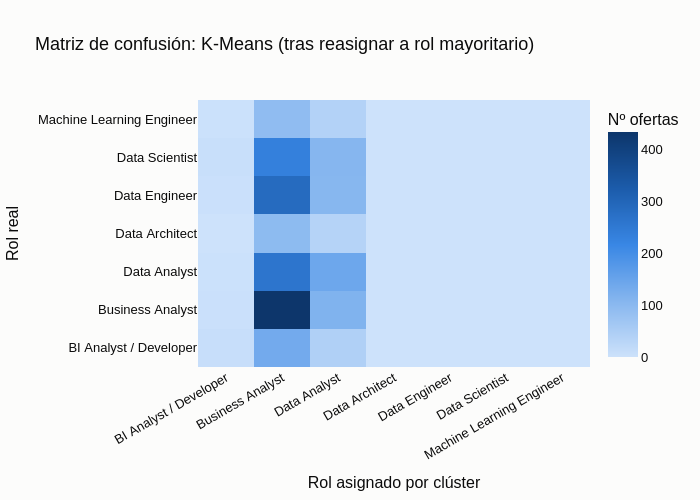

In [57]:
etiquetas_roles = sorted(y.unique())
matriz_confusion_kmeans = confusion_matrix(y, etiquetas_kmeans, labels=etiquetas_roles)
matriz_confusion_kmeans_df = pd.DataFrame(matriz_confusion_kmeans, index=etiquetas_roles, columns=etiquetas_roles)

fig = go.Figure(data=go.Heatmap(
    z=matriz_confusion_kmeans_df.values,
    x=matriz_confusion_kmeans_df.columns,
    y=matriz_confusion_kmeans_df.index,
    colorscale=colorscale_azul,
    colorbar=dict(title='Nº ofertas'),
    hovertemplate='Real: %{y}<br>Clúster reasignado: %{x}<br>%{z} ofertas<extra></extra>',
))

fig.update_layout(
    title='Matriz de confusión: K-Means (tras reasignar a rol mayoritario)',
    xaxis_title='Rol asignado por clúster',
    yaxis_title='Rol real',
    plot_bgcolor='#fcfcfb',
    paper_bgcolor='#fcfcfb',
    font=dict(color='#0b0b0b', size=13),
    margin=dict(l=180, b=120),
)
fig.update_xaxes(tickangle=-30)
fig.show()

Varianza explicada por las 2 componentes: 12.46%


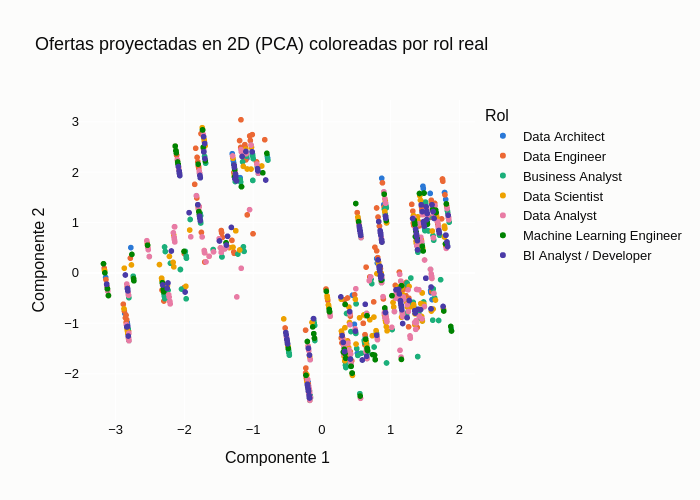

In [58]:
from sklearn.decomposition import PCA
import plotly.express as px

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_escalado)

print(f"Varianza explicada por las 2 componentes: {pca.explained_variance_ratio_.sum():.2%}")

paleta_roles = ['#2a78d6', '#eb6834', '#1baf7a', '#eda100', '#e87ba4', '#008300', '#4a3aa7']

fig = px.scatter(
    x=X_pca[:, 0], y=X_pca[:, 1],
    color=y,
    color_discrete_sequence=paleta_roles,
    title='Ofertas proyectadas en 2D (PCA) coloreadas por rol real',
    labels={'x': 'Componente 1', 'y': 'Componente 2', 'color': 'Rol'},
)
fig.update_layout(plot_bgcolor='#fcfcfb', paper_bgcolor='#fcfcfb', font=dict(color='#0b0b0b', size=13))
fig.show()

## 5️⃣ Qué reveló K-Means: el perfil de cada clúster
En vez de quedarnos en que los clústeres no coinciden con los roles, perfilamos cada uno para ver qué segmentación real del mercado encontró el algoritmo.

In [59]:
df['cluster_kmeans'] = clusters

resumen_clusters = df.groupby('cluster_kmeans').agg(
    num_ofertas=('cluster_kmeans', 'size'),
    industria_principal=('industria_principal', lambda x: x.mode()[0]),
    modalidad_remoto=('modalidad_remoto', lambda x: x.mode()[0]),
    experiencia_principal=('formatted_experience_level', lambda x: x.mode()[0]),
    num_skills_media=('num_skills', 'mean'),
).round(2)

resumen_clusters

,num_ofertas,industria_principal,modalidad_remoto,experiencia_principal,num_skills_media
cluster_kmeans,,,,,
0,75,Technology,No especificado,Mid-Senior level,3.12
1,30,Telecommunications,No especificado,Mid-Senior level,3.80
2,1307,IT Services and IT Consulting,No especificado,Mid-Senior level,4.13
3,20,Higher Education,No especificado,Mid-Senior level,1.95
4,66,Insurance,No especificado,Mid-Senior level,3.77
5,572,IT Services and IT Consulting,Remoto,Mid-Senior level,4.32
6,93,Staffing and Recruiting,No especificado,Mid-Senior level,3.52


In [60]:
tabla_cluster_rol = pd.crosstab(df['cluster_kmeans'], df['categoria_rol'], normalize='index').round(3) * 100
tabla_cluster_rol

categoria_rol,BI Analyst / Developer,Business Analyst,Data Analyst,Data Architect,Data Engineer,Data Scientist,Machine Learning Engineer
cluster_kmeans,,,,,,,
0,8.0,26.7,16.0,5.3,9.3,18.7,16.0
1,30.0,13.3,10.0,0.0,13.3,23.3,10.0
2,8.5,28.2,16.8,6.3,18.8,15.5,5.9
3,0.0,30.0,45.0,0.0,0.0,15.0,10.0
4,15.2,27.3,18.2,7.6,12.1,16.7,3.0
5,7.7,19.2,23.4,6.3,18.5,18.4,6.5
6,8.6,28.0,19.4,6.5,28.0,7.5,2.2
